# Введение в машинное обучение — простыми словами

Это **упрощённая копия** учебного ноутбука «Введение в машинное обучение».

Здесь **нет** сложных формул и производных.
Мы идём маленькими шагами: от «что это вообще такое» до «как обучить простую модель в Python».

**Что понадобится**
- Python (удобнее всего Jupyter / JupyterLab / VS Code / Google Colab)
- Библиотеки: `numpy`, `scikit-learn`, `matplotlib` (обычно уже есть в Anaconda)

Запускайте ячейки **по порядку** (сверху вниз).


## План

1. Что такое машинное обучение (на пальцах)
2. Какие бывают задачи (с учителем / без учителя)
3. Пример 0: угадываем правило «в уме»
4. Пример 1: одна переменная — площадь квартиры → цена
5. Пример 2: несколько переменных (как в основном ноутбуке, но проще)
6. Как понять, что модель ошибается
7. Что такое полиномы (простыми словами)
8. Переобучение — когда модель «вызубрила», а не «поняла»
9. Словарь терминов и что делать дальше


## 1. Что такое машинное обучение

### Обычная программа vs обучение

**Обычная программа** — вы сами пишете правила:

> «Если температура выше 100 — кипит вода»
> «Если возраст < 18 — нельзя в этот раздел»

**Машинное обучение** — вы **не** пишете все правила вручную.
Вы даёте компьютеру **примеры**, а он сам находит закономерность.

### Аналогия: ребёнок учится узнавать кошку

Вы не объясняете ребёнку формулы.
Вы показываете много картинок: «это кошка», «это собака».
Потом ребёнок сам узнаёт новую кошку, которой раньше не видел.

Машинное обучение делает примерно то же самое — только с числами, таблицами, картинками, текстом.

### Ещё одна аналогия: калькулятор vs камера на дороге

| | Калькулятор | Камера ПДД |
|---|---|---|
| Правила | Все запрограммированы заранее | Часть поведения «выучена» из данных |
| Новая ситуация | Считает по формуле | Должен узнать машину, даже если она чуть другая |

### Когда ML **не** нужен

Если правило уже известно и простое — не надо ML.

Пример: `сила = масса × ускорение`.
Тут нет смысла «обучать модель» — формула уже есть.

ML полезен, когда:
- правило **неизвестно** или слишком сложное, чтобы написать руками;
- есть **много примеров** (данные);
- хотим **предсказывать** что-то новое по похожим примерам.


## 2. Два больших направления и два типа задач

### Классическое ML vs «глубокое» обучение

**Классическое машинное обучение** (то, с чего обычно начинают):
- таблицы с числами, категориями («да/нет», «город», «тип квартиры»);
- работает и на маленьких данных (десятки–тысячи строк);
- модели вроде линейной регрессии, деревьев решений и т.д.

**Глубокое обучение (deep learning)**:
- картинки, видео, звук, длинные тексты;
- обычно нужны **очень** большие данные и мощные компьютеры;
- нейронные сети.

Сейчас мы в **классическом** ML и на самом простом уровне.

### Обучение **с учителем** (supervised)

У каждого примера есть **правильный ответ**.

| Площадь (м²) | Цена (у.е.) |
|---|---|
| 30 | 3 000 000 |
| 50 | 5 000 000 |
| 80 | 8 200 000 |

Модель учится: «площадь → цена», а потом предсказывает цену для **новой** квартиры.

Другие примеры:
- спам / не спам (по тексту письма);
- болен / здоров (по анализам);
- какая цифра на фото (0–9).

### Обучение **без учителя** (unsupervised)

Ответов **нет**. Есть только «сырые» объекты.

Задача: найти структуру — например, **разбить клиентов на группы** (кластеры) по похожести.

Аналогия: разложить кучу носков по парам **без** подписей — просто по сходству.

В этом ноутбуке дальше — только **обучение с учителем** и самая простая модель: **линейная регрессия**
(«провести прямую линию через точки» / «подобрать простую формулу»).


## 3. Пример 0 — «обучение» без библиотек (совсем примитивно)

Представим: нам дали 3 примера, как связаны `x` и `y`:

| x | y |
|---|---|
| 1 | 3 |
| 2 | 5 |
| 3 | 7 |

Заметили?
`y = 2 * x + 1`

То есть:
- берём `x`,
- умножаем на **2**,
- прибавляем **1**.

Это и есть «модель» в самом простом виде:

> **y ≈ a · x + b**

где:
- `a` — «наклон» (насколько y растёт, когда x растёт на 1),
- `b` — «сдвиг» (что будет, если x = 0).

В нашем случае `a = 2`, `b = 1`.

Ниже — «предсказание» вручную на Python (без sklearn).


In [1]:
# Наши «обучающие» примеры
xs = [1, 2, 3]
ys = [3, 5, 7]

# Мы «на глаз» поняли правило
a = 2
b = 1

def predict(x):
    # Предсказать y по x: y = a*x + b
    return a * x + b

# Проверим, что на известных примерах всё сходится
for x, y_true in zip(xs, ys):
    y_pred = predict(x)
    print(f"x={x}: правда={y_true}, предсказание={y_pred}, ошибка={y_pred - y_true}")

# А теперь — для НОВОГО x, которого не было в таблице
print("Предсказание для x=10:", predict(10))

x=1: правда=3, предсказание=3, ошибка=0
x=2: правда=5, предсказание=5, ошибка=0
x=3: правда=7, предсказание=7, ошибка=0
Предсказание для x=10: 21


### Что мы только что сделали (это и есть схема ML)

1. **Данные** — примеры `(x, y)`.
2. **Модель** — формула `y = a*x + b`.
3. **Параметры** — числа `a` и `b` (их модель «подбирает»).
4. **Предсказание** — ответ для нового `x`.

В реальном ML параметры `a` и `b` компьютер **сам** подбирает, глядя на данные.
Мы это сделаем чуть позже через `sklearn`.


## 4. Пример 1 — цена квартиры по площади (1 признак)

**Задача:** по площади квартиры (в м²) предсказать цену.

Чтобы не путаться, **сами придумаем** «настоящую» зависимость и чуть добавим «шум»
(в жизни цены не идеально ложатся на формулу — бывают случайные отклонения).

Пусть «настоящая» цена примерно такая:

> цена ≈ 100 000 × площадь + 500 000

То есть:
- каждый метр «стоит» около 100 000,
- плюс базовая сумма 500 000 (типа «минимум за саму квартиру»).

Модель **не знает** эту формулу.
Она видит только таблицу «площадь → цена» и должна **восстановить** похожие числа.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Чтобы у всех результаты были одинаковые при повторном запуске
np.random.seed(42)

# 8 квартир с разной площадью
area = np.array([30, 35, 40, 45, 50, 60, 70, 80], dtype=float)

# «Настоящая» цена + небольшой случайный шум
noise = np.random.normal(0, 200_000, size=len(area))  # шум примерно ±200 тыс.
price = 100_000 * area + 500_000 + noise

print("Площадь (м²):", area)
print("Цена:", np.round(price).astype(int))

Площадь (м²): [30. 35. 40. 45. 50. 60. 70. 80.]
Цена: [3599343 3972347 4629538 5304606 5453169 6453173 7815843 8653487]


### Нарисуем точки

Каждая точка — одна квартира:
по горизонтали площадь, по вертикали цена.


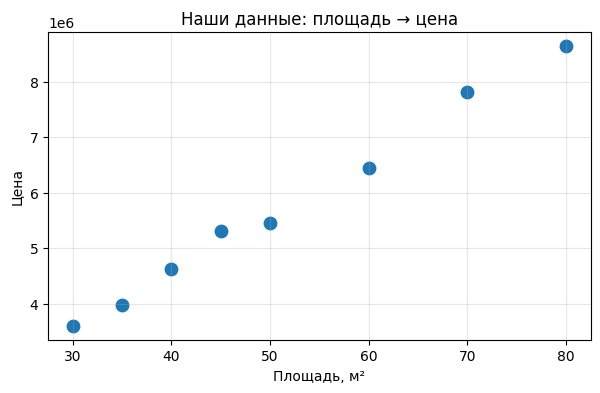

In [3]:
plt.figure(figsize=(7, 4))
plt.scatter(area, price, s=80)
plt.xlabel("Площадь, м²")
plt.ylabel("Цена")
plt.title("Наши данные: площадь → цена")
plt.grid(True, alpha=0.3)
plt.show()

### Обучаем линейную регрессию

Библиотека `sklearn` уже умеет подбирать `a` и `b` в формуле:

> цена ≈ a · площадь + b

Три шага:
1. **Создать** модель
2. **Обучить** (`fit`) на данных
3. **Посмотреть**, какие числа она нашла (`coef_`, `intercept_`)

`sklearn` ждёт, чтобы `X` был **таблицей** (даже если столбец один).
Поэтому делаем `area.reshape(-1, 1)` — «столбец из площадей».


In [4]:
from sklearn.linear_model import LinearRegression

# X — то, по чему предсказываем (признаки)
# y — то, что предсказываем (ответ)
X = area.reshape(-1, 1)  # форма: 8 строк, 1 столбец
y = price

model = LinearRegression()   # 1) создали «пустую» модель
model.fit(X, y)              # 2) обучили на наших 8 квартирах

a = model.coef_[0]           # коэффициент перед площадью. 0 потому что формула = ax + b, если ax + by + c, тогда метод intercept_ будет искать c, а метод coef_ будет содержать список из a и b [0] и [1] 
b = model.intercept_         # свободный член (сдвиг)

print("Модель нашла:")
print(f"  a (сколько «стоит» 1 м²) ≈ {a:,.0f}")
print(f"  b (базовая часть цены)   ≈ {b:,.0f}")
print()
print("Напоминание: мы сами заложили примерно a=100000, b=500000")
print("Модель почти угадала — шум немного «сбил» точные числа.")

Модель нашла:
  a (сколько «стоит» 1 м²) ≈ 102,321
  b (базовая часть цены)   ≈ 491,244

Напоминание: мы сами заложили примерно a=100000, b=500000
Модель почти угадала — шум немного «сбил» точные числа.


### Откуда берутся `a` и `b`? (ручной просчёт)

После `model.fit(X, y)` у модели появляются два числа:

| Код | Что это | Роль в формуле `цена ≈ a · площадь + b` |
|---|---|---|
| `model.coef_[0]` | `a` | на сколько растёт цена, если площадь +1 м² |
| `model.intercept_` | `b` | «базовая» часть цены (условно при площади 0) |

**Важно:** sklearn **не выдумывает** эти числа из воздуха.  
Он **считает** их по обучающим данным. Мы можем сделать то же самое **вручную** на крошечном примере.

---

#### Шаг 0. Возьмём 3 квартиры с «красивыми» числами

Чтобы считать в уме, цену пишем **в миллионах рублей** (3.5 = 3 500 000 ₽).

| Квартира | Площадь $x$ (м²) | Цена $y$ (млн ₽) |
|---|---|---|
| 1 | 30 | 3.5 |
| 2 | 50 | 5.5 |
| 3 | 70 | 7.5 |

Заметьте: когда площадь растёт на 20 м², цена растёт на 2 млн.  
Значит, «на глаз» 1 м² стоит $2 / 20 = 0.1$ млн = **100 000 ₽**.  
База: при 50 м² цена 5.5 → $b = 5.5 - 0.1 \cdot 50 = 0.5$ млн.  

Ниже — **тот же ответ**, но по стандартным школьным формулам линейной регрессии.

---

#### Шаг 1. Средние значения

$$\bar{x} = \frac{30 + 50 + 70}{3} = \frac{150}{3} = 50$$

$$\bar{y} = \frac{3.5 + 5.5 + 7.5}{3} = \frac{16.5}{3} = 5.5$$

Средняя квартира: **50 м²** и **5.5 млн**.

---

#### Шаг 2. Отклонения от среднего

Для каждой квартиры: «насколько $x$ отличается от 50» и «насколько $y$ отличается от 5.5».

| $x$ | $x - \bar{x}$ | $y$ | $y - \bar{y}$ | произведение $(x-\bar{x})(y-\bar{y})$ | $(x-\bar{x})^2$ |
|---|---|---|---|---|---|
| 30 | −20 | 3.5 | −2.0 | (−20)·(−2) = **40** | 400 |
| 50 | 0 | 5.5 | 0 | 0 | 0 |
| 70 | +20 | 7.5 | +2.0 | 20·2 = **40** | 400 |
| **сумма** | | | | **80** | **800** |

**Смысл произведения:**  
если $x$ выше среднего **и** $y$ выше среднего (или оба ниже) — точки «идут в одну сторону», сумма произведений большая → наклон $a$ будет заметным.

---

#### Шаг 3. Считаем $a$ (наклон)

Формула (для **одной** переменной):

$$a = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2} = \frac{80}{800} = 0.1$$

То есть **0.1 млн ₽ за 1 м²** = **100 000 ₽/м²**.

Простыми словами:

> $a$ = «насколько вместе гуляют площадь и цена»  
> делится на «насколько разбросана площадь».

---

#### Шаг 4. Считаем $b$ (сдвиг)

Формула:

$$b = \bar{y} - a \cdot \bar{x} = 5.5 - 0.1 \cdot 50 = 5.5 - 5 = 0.5$$

То есть **0.5 млн ₽** = **500 000 ₽**.

**Смысл:** прямая должна пройти через «центр облака точек» $(\bar{x}, \bar{y})$.  
Если знаем наклон $a$, то $b$ однозначно находится:  
«от средней цены отнимаем $a \cdot$ среднюю площадь».

---

#### Шаг 5. Готовая формула

$$\text{цена (млн)} \approx 0.1 \cdot \text{площадь} + 0.5$$

или в рублях:

$$\text{цена} \approx 100\,000 \cdot \text{площадь} + 500\,000$$

Проверка на квартире 55 м²:

$$0.1 \cdot 55 + 0.5 = 5.5 + 0.5 = 6.0 \text{ млн} = 6\,000\,000 \text{ ₽}$$

---

### Связь с `model.coef_` и `model.intercept_`

Когда вы пишете:

```python
model = LinearRegression()
model.fit(X, y)
a = model.coef_[0]
b = model.intercept_
```

происходит следующее:

1. **`fit(X, y)`** — «посмотри на все пары (площадь, цена) и **вычисли** лучшие $a$ и $b$».  
   Для одного признака это **те же формулы**, что выше (для нескольких признаков — обобщение, система уравнений).
2. **`model.coef_`** — массив коэффициентов перед признаками.  
   У нас один признак (площадь) → массив из одного числа → берём `coef_[0]`.  
   Если бы признаков было 3, было бы `coef_ = [a1, a2, a3]`.
3. **`model.intercept_`** — это как раз $b$, свободный член (intercept = «перехват» оси, сдвиг).

То есть:

| Что выводит код | Откуда число |
|---|---|
| `model.coef_[0]` | Посчитано из данных при `fit` (у нас вручную вышло 0.1 млн/м²) |
| `model.intercept_` | Посчитано из данных при `fit` (у нас вручную вышло 0.5 млн) |

**Почему в ячейке с 8 квартирами числа не ровно 100000 и 500000?**  
Потому что туда добавлен **шум**: цены чуть «пляшут».  
Sklearn всё равно считает $a$ и $b$ по формулам, но уже по «шумным» точкам — поэтому ответ **близкий**, но не идеально круглый.

Ниже — проверка: ручной расчёт и `LinearRegression` на тех же 3 квартирах дают **одинаковый** результат.


In [5]:
# Те же 3 квартиры, что в ручном расчёте (цена в миллионах)
x_hand = np.array([30.0, 50.0, 70.0])
y_hand = np.array([3.5, 5.5, 7.5])

# ----- способ 1: формулы «как на бумаге» -----
x_mean = x_hand.mean()
y_mean = y_hand.mean()

# числитель: сумма (x - среднее_x) * (y - среднее_y)
numer = ((x_hand - x_mean) * (y_hand - y_mean)).sum()
# знаменатель: сумма (x - среднее_x)^2
denom = ((x_hand - x_mean) ** 2).sum()

a_hand = numer / denom
b_hand = y_mean - a_hand * x_mean

print("Ручной расчёт:")
print(f"  среднее x = {x_mean}, среднее y = {y_mean}")
print(f"  числитель = {numer}, знаменатель = {denom}")
print(f"  a = {a_hand} млн/м²  (= {a_hand * 1_000_000:.0f} ₽/м²)")
print(f"  b = {b_hand} млн     (= {b_hand * 1_000_000:.0f} ₽)")

# ----- способ 2: то, что делает sklearn -----
model_hand = LinearRegression()
model_hand.fit(x_hand.reshape(-1, 1), y_hand)

print()
print("Sklearn после fit:")
print(f"  model.coef_[0]   = {model_hand.coef_[0]}   ← это a")
print(f"  model.intercept_ = {model_hand.intercept_} ← это b")
print()
print("Совпадает?",
      np.isclose(a_hand, model_hand.coef_[0]) and np.isclose(b_hand, model_hand.intercept_))

Ручной расчёт:
  среднее x = 50.0, среднее y = 5.5
  числитель = 80.0, знаменатель = 800.0
  a = 0.1 млн/м²  (= 100000 ₽/м²)
  b = 0.5 млн     (= 500000 ₽)

Sklearn после fit:
  model.coef_[0]   = 0.09999999999999999   ← это a
  model.intercept_ = 0.5 ← это b

Совпадает? True


### Предскажем цену новой квартиры

Допустим, появилась квартира **55 м²**, которой не было в обучающих данных.


In [6]:
new_area = np.array([[55.0]])  # снова «таблица» 1×1
pred = model.predict(new_area)[0]
print(f"Предсказанная цена для 55 м²: {pred:,.0f}")

Предсказанная цена для 55 м²: 6,118,891


### Нарисуем линию модели поверх точек

Прямая — это и есть то, что «выучила» модель.


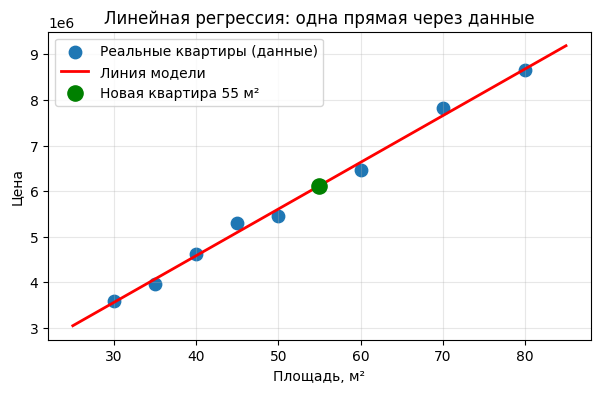

In [7]:
# Линия: предсказания модели на диапазоне площадей
line_x = np.linspace(25, 85, 100).reshape(-1, 1)
line_y = model.predict(line_x)

plt.figure(figsize=(7, 4))
plt.scatter(area, price, s=80, label="Реальные квартиры (данные)")
plt.plot(line_x, line_y, color="red", linewidth=2, label="Линия модели")
plt.scatter([55], [pred], color="green", s=120, zorder=5, label="Новая квартира 55 м²")
plt.xlabel("Площадь, м²")
plt.ylabel("Цена")
plt.title("Линейная регрессия: одна прямая через данные")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Мини-вывод по примеру 1

- Модель ищет **простую** формулу: прямую линию.
- Ей не нужно знать «настоящую» формулу — достаточно примеров.
- Чем меньше шума и чем больше хороших примеров, тем ближе она к правде.

В основном учебном ноутбуке делают то же самое, но сразу с **тремя** числами `t, s, z`.
Ниже — упрощённая версия той же идеи.


## 5. Пример 2 — несколько признаков (как в основном ноутбуке)

В основном ноутбуке генерируют таблицу `X` размера 7×3
(7 объектов, у каждого 3 числа) и собирают `y` по формуле:

> y = 25·t + 100·s − 42·z + 81 + шум

**Простыми словами:**
- у каждого объекта есть 3 «кнопки» / 3 характеристики: `t`, `s`, `z`;
- ответ `y` почти линейно зависит от них;
- шум — небольшая случайная «помеха», как в жизни;
- модель должна **сама** найти числа примерно `25`, `100`, `−42` и сдвиг `81`.

Сначала сделаем **совсем маленькую** таблицу руками, чтобы было видно глазами.


In [8]:
# 4 объекта, 3 признака (t, s, z) — выдуманные, но наглядные
# Столбцы: t, s, z
X_small = np.array([
    [1, 0, 1],
    [2, 1, 1],
    [3, 0, 2],
    [4, 1, 2],
], dtype=float)

print("Признаки X (строка = объект, столбцы = t, s, z):")
print(X_small)

# Собираем y почти по правилу: 25*t + 100*s - 42*z + 81
# (без шума, чтобы числа были «чистыми»)
true_a = np.array([25, 100, -42])
true_b = 81
y_clean = X_small @ true_a + true_b  # то же, что 25*t + 100*s - 42*z + 81
print("\ny (без шума):", y_clean)

Признаки X (строка = объект, столбцы = t, s, z):
[[1. 0. 1.]
 [2. 1. 1.]
 [3. 0. 2.]
 [4. 1. 2.]]

y (без шума): [ 64. 189.  72. 197.]


### Обучим модель на этой крошечной таблице

Если шума нет и формула линейная — модель обычно находит коэффициенты **очень точно**.


In [9]:
model2 = LinearRegression()
model2.fit(X_small, y_clean)

print("Истинные коэффициенты:     ", true_a, "  сдвиг:", true_b)
print("Коэффициенты модели coef_:", np.round(model2.coef_, 5), "  сдвиг:", round(model2.intercept_, 5))

Истинные коэффициенты:      [ 25 100 -42]   сдвиг: 81
Коэффициенты модели coef_: [ 23.5 101.5 -39. ]   сдвиг: 79.5


### Теперь — ближе к основному ноутбуку: случайные данные + шум

Ниже почти тот же код, что в уроке, но с комментариями «что означает каждая строка».


In [10]:
np.random.seed(7)

# 7 объектов, 3 признака; числа от 0 до 99
X_multi = np.random.randint(100, size=(7, 3))
print("X (таблица признаков):\n", X_multi)

# y = 25*t + 100*s - 42*z + 81 + шум
# np.dot — «умное умножение»: для каждой строки X умножить на [25,100,-42] и сложить
y_multi = np.dot(X_multi, np.array([25, 100, -42])) + 81 + np.random.normal(0, 10, size=7)
print("\ny (ответы с шумом):\n", np.round(y_multi, 2))

X (таблица признаков):
 [[47 68 25]
 [67 83 23]
 [92 57 14]
 [23 72 89]
 [42 90  8]
 [39 68 48]
 [ 7 44  0]]

y (ответы с шумом):
 [7004.37 9086.66 7492.85 4118.21 9802.49 5839.17 4656.71]


In [11]:
model3 = LinearRegression()
model3.fit(X_multi, y_multi)

print("Модель нашла коэффициенты:", np.round(model3.coef_, 2))
print("Модель нашла сдвиг:       ", round(model3.intercept_, 2))
print()
print("Мы загадывали примерно:     [25, 100, -42] и сдвиг 81")
print()
print("Почему не ровно 25, 100, -42, 81?")
print("Потому что мы добавили шум, и объектов всего 7 — маловато.")
print("Но порядок величин и знаки модель обычно ловит уже так.")

Модель нашла коэффициенты: [ 24.95 100.11 -42.05]
Модель нашла сдвиг:        77.69

Мы загадывали примерно:     [25, 100, -42] и сдвиг 81

Почему не ровно 25, 100, -42, 81?
Потому что мы добавили шум, и объектов всего 7 — маловато.
Но порядок величин и знаки модель обычно ловит уже так.


### Предсказание для нового объекта

Новый объект = три новых числа `(t, s, z)`.


In [12]:
new_object = np.array([[10, 2, 5]])  # t=10, s=2, z=5
pred_new = model3.predict(new_object)[0]

# Для сравнения — «идеальный» ответ без шума
ideal = 25*10 + 100*2 - 42*5 + 81

print("Предсказание модели:", round(pred_new, 2))
print("Идеал без шума:     ", ideal)

Предсказание модели: 317.12
Идеал без шума:      321


## 6. Как понять, что модель ошибается (без страшной математики)

В основном ноутбуке много формул про **MSE** (mean squared error — среднюю квадратичную ошибку).

**Идея одной фразой:**

> Смотрим, насколько предсказание далеко от правды.
> Чем дальше — тем «больнее». Квадрат ошибки сильнее наказывает большие промахи.

### Совсем простой способ: средняя абсолютная ошибка

Для каждой квартиры:
1. предсказали цену,
2. вычли из настоящей,
3. взяли модуль (минус не важен — важно «на сколько ошиблись»),
4. усреднили по всем квартирам.

Это и есть MAE (mean absolute error) — среднее «на сколько мы промахнулись».


In [13]:
# Вернёмся к квартирам (пример 1)
y_pred = model.predict(X)
errors = y_pred - y
abs_errors = np.abs(errors)

print("Настоящая цена | Предсказание | Ошибка | |Ошибка|")
for true, pred, err, aerr in zip(y, y_pred, errors, abs_errors):
    print(f"{true:12.0f} | {pred:12.0f} | {err:8.0f} | {aerr:8.0f}")

mae = abs_errors.mean()
print()
print(f"Средняя ошибка по модулю (MAE): {mae:,.0f}")
print("Читать так: в среднем модель ошибается примерно на эту сумму.")

Настоящая цена | Предсказание | Ошибка | |Ошибка|
     3599343 |      3560870 |   -38473 |    38473
     3972347 |      4072474 |   100127 |   100127
     4629538 |      4584078 |   -45459 |    45459
     5304606 |      5095683 |  -208923 |   208923
     5453169 |      5607287 |   154118 |   154118
     6453173 |      6630496 |   177323 |   177323
     7815843 |      7653704 |  -162138 |   162138
     8653487 |      8676913 |    23426 |    23426

Средняя ошибка по модулю (MAE): 113,748
Читать так: в среднем модель ошибается примерно на эту сумму.


### MSE — «та же идея, но с квадратом»

Вместо |ошибка| считают (ошибка)² и усредняют.

Зачем квадрат?
- большие ошибки становятся **заметнее**;
- математически с этим удобнее работать алгоритмам (в учебном ноутбуке как раз выводят формулы).

**Вам на старте достаточно понимать:**
- есть «настоящий ответ» и «ответ модели»;
- есть число, которое показывает «насколько плохо»;
- обучение = **подобрать параметры так, чтобы это число стало поменьше**.

Всё. Производные можно отложить.


In [14]:
# mse = 0
# for true, pred, err, aerr in zip(y, y_pred, errors, abs_errors):
#     mse += err**2
    
# mse = mse / len(abs_errors)
# print(mse)

mse = np.mean((y - y_pred) ** 2)
print(mse)


17406798077.540405


## 7. Что такое полиномы (простыми словами)

В следующем разделе появятся слова **«полином степени 1 / 4 / 20»**.  
Сначала разберём, **что это такое**, без «страшной» математики.

### Аналогия: конструктор из кусочков $x$

Полином — это **формула**, собранная из:
- числа (коэффициенты),
- переменной $x$,
- степеней $x$: $x^2$, $x^3$, …,
- сложения и умножения.

Общий вид (одной переменной):

$$y = a_0 + a_1 x + a_2 x^2 + a_3 x^3 + \ldots + a_n x^n$$

Где:
- $a_0, a_1, a_2, \ldots$ — числа, которые можно подбирать (как рычаги);
- $n$ — **степень** полинома (самая высокая степень $x$).

**Степень** = «насколько изогнутой может быть линия».

| Степень | Пример формулы | Как выглядит на графике |
|---|---|---|
| 0 | $y = 5$ | горизонтальная прямая |
| 1 | $y = 2x + 1$ | **наклонная прямая** |
| 2 | $y = x^2 - 3x + 2$ | **парабола** (одна «чаша» / дуга) |
| 3 | $y = x^3 - x$ | волна с **двумя** изгибами |
| высокая (10, 20…) | много слагаемых $x^{10}$, $x^{20}$… | линия может **сильно извиваться** |

### Связь с тем, что мы уже делали

Линейная регрессия из раздела 4 — это как раз **полином степени 1**:

$$\text{цена} \approx a \cdot \text{площадь} + b$$

То есть $y = a_1 x + a_0$.  
Прямая — самый простой полином.

### Зачем в ML поднимают степень?

Иногда данные **не лежат на прямой**, а идут дугой или волной.

Тогда можно оставить ту же `LinearRegression`, но **добавить новые столбцы-признаки**:  
не только $x$, а ещё $x^2$, $x^3$, …

Пример: было

| $x$ |
|---|
| 2 |

стало (степень 3):

| $1$ | $x$ | $x^2$ | $x^3$ |
|---|---|---|---|
| 1 | 2 | 4 | 8 |

Модель по-прежнему «линейная» по коэффициентам $a_0, a_1, a_2, a_3$,  
но **линия на графике** уже может быть кривой, потому что в формуле есть $x^2$, $x^3$.

Именно это делает `PolynomialFeatures` в sklearn:
> «Возьми $x$ и сделай из него $1, x, x^2, \ldots, x^n$».

### Важная мысль одной фразой

> **Чем выше степень полинома — тем гибче кривая.**  
> Гибкость помогает описать сложную форму,  
> но слишком большая гибкость легко **подгоняется под шум** (это уже переобучение — следующий раздел).

Ниже — маленький визуальный пример: одни и те же $x$, разные степени.


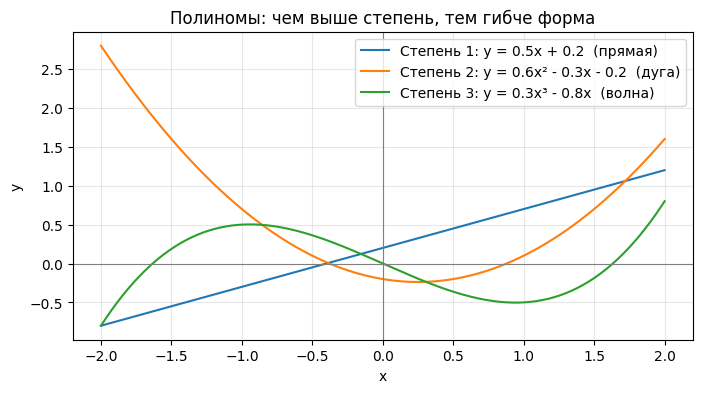

Степень 1 → только прямая.
Степень 2 → может согнуться один раз (парабола).
Степень 3 → может изогнуться сильнее.
Степень 20 (в следующем разделе) → почти любая «змейка» через точки.


In [15]:
# Нарисуем полиномы разных степеней на одном графике
# (это НЕ обучение модели — просто «как выглядит формула»)

x = np.linspace(-2, 2, 200)

# Степень 1: прямая
y1 = 0.5 * x + 0.2

# Степень 2: парабола
y2 = 0.6 * x**2 - 0.3 * x - 0.2

# Степень 3: более «волнистая» кривая
y3 = 0.3 * x**3 - 0.8 * x

plt.figure(figsize=(8, 4))
plt.plot(x, y1, label="Степень 1: y = 0.5x + 0.2  (прямая)")
plt.plot(x, y2, label="Степень 2: y = 0.6x² - 0.3x - 0.2  (дуга)")
plt.plot(x, y3, label="Степень 3: y = 0.3x³ - 0.8x  (волна)")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Полиномы: чем выше степень, тем гибче форма")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Степень 1 → только прямая.")
print("Степень 2 → может согнуться один раз (парабола).")
print("Степень 3 → может изогнуться сильнее.")
print("Степень 20 (в следующем разделе) → почти любая «змейка» через точки.")

### Очень простой пример: целые числа и $y = x^2$

График выше — для наглядности «как выглядит» формула.  
Теперь — **крошечный рабочий пример** на 4 точках, только целые числа.

**Идея:** «настоящее» правило совсем простое:

$$y = x^2$$

| $x$ | $y = x^2$ |
|---|---|
| 1 | 1 |
| 2 | 4 |
| 3 | 9 |
| 4 | 16 |

Мы **не** скажем модели формулу.  
Дадим только таблицу $(x, y)$ и попросим подобрать полином **степени 2**:

$$y \approx a_0 + a_1 x + a_2 x^2$$

Если всё хорошо, модель найдёт примерно: $a_0 = 0$, $a_1 = 0$, $a_2 = 1$  
(то есть «просто $x^2$»).

Потом спросим: что будет при $x = 5$? Правильный ответ — $25$.


x: [1 2 3 4]
y: [ 1  4  9 16]

Таблица x | x^2 | y:
  1 | 1 | 1
  2 | 4 | 4
  3 | 9 | 9
  4 | 16 | 16

Признаки для модели (столбцы: 1, x, x^2):
[[ 1  1  1]
 [ 1  2  4]
 [ 1  3  9]
 [ 1  4 16]]

Модель нашла коэффициенты:
  a0 (при 1)  ≈ 0.000   (ждали 0)
  a1 (при x)  ≈ -0.000   (ждали 0)
  a2 (при x²) ≈ 1.000   (ждали 1)

То есть выучила примерно: y ≈ 0 + 0*x + 1*x²  →  y ≈ x²

Прогноз для x=5: 25.0   (правильный ответ: 25)


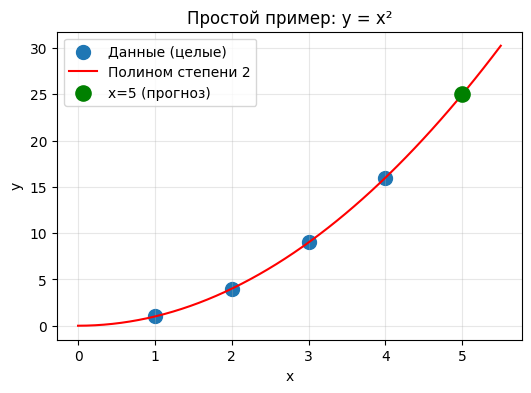

In [21]:
# --- Очень простой полином: y = x^2, целые числа ---
from sklearn.preprocessing import PolynomialFeatures

# 1) Маленькие целые данные (всего 4 точки)
x_simple = np.array([1, 2, 3, 4])
y_simple = np.array([1, 4, 9, 16])  # это x*x

print("x:", x_simple)
print("y:", y_simple)
print()

# 2) Смотрим «глазами»: x и x^2
print("Таблица x | x^2 | y:")
for x_i, y_i in zip(x_simple, y_simple):
    print(f"  {x_i} | {x_i**2} | {y_i}")
print()

# 3) Делаем признаки полинома степени 2: столбцы 1, x, x^2
poly_simple = PolynomialFeatures(degree=2)  # include_bias=True → есть столбец единиц
X_simple = poly_simple.fit_transform(x_simple.reshape(-1, 1))
print("Признаки для модели (столбцы: 1, x, x^2):")
print(X_simple.astype(int))
print()

# 4) Обучаем обычную линейную регрессию на этих признаках
# fit_intercept=False: свободный член уже есть в столбце «1»
model_simple = LinearRegression(fit_intercept=False)
model_simple.fit(X_simple, y_simple)

a0, a1, a2 = model_simple.coef_
print("Модель нашла коэффициенты:")
print(f"  a0 (при 1)  ≈ {a0:.3f}   (ждали 0)")
print(f"  a1 (при x)  ≈ {a1:.3f}   (ждали 0)")
print(f"  a2 (при x²) ≈ {a2:.3f}   (ждали 1)")
print()
print("То есть выучила примерно: y ≈ 0 + 0*x + 1*x²  →  y ≈ x²")
print()

# 5) Предсказание для нового x=5 (в обучении его не было)
X_new = poly_simple.transform(np.array([[5]]))
pred5 = model_simple.predict(X_new)[0]
print(f"Прогноз для x=5: {pred5:.1f}   (правильный ответ: 25)")

# 6) Маленький график: точки + кривая модели
x_line_s = np.linspace(0, 5.5, 50).reshape(-1, 1)
y_line_s = model_simple.predict(poly_simple.transform(x_line_s))

plt.figure(figsize=(6, 4))
plt.scatter(x_simple, y_simple, s=100, label="Данные (целые)")
plt.plot(x_line_s, y_line_s, color="red", label="Полином степени 2")
plt.scatter([5], [pred5], color="green", s=120, zorder=5, label="x=5 (прогноз)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Простой пример: y = x²")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Мини-вывод про полиномы

1. Полином — формула вида $a_0 + a_1 x + a_2 x^2 + \ldots$.
2. **Степень** = максимальная сила $x$ (и грубо — «гибкость» линии).
3. Обычная линейная регрессия = полином **степени 1**.
4. `PolynomialFeatures(degree=n)` добавляет $x^2, \ldots, x^n$, чтобы линия могла гнуться.
5. Дальше увидим: степень 1 / 4 / 20 на одних и тех же данных — от «слишком просто» до «переучился».


## 8. Переобучение — «вызубрил», а не «поняла»

Представьте экзамен:
- ученик **выучил наизусть** все задачи из учебника;
- на контрольной дали **похожие, но новые** — и он растерялся.

Так бывает и у моделей.

В разделе 7 мы разобрали, что **полином** — это формула с $x$, $x^2$, $x^3$, …, а **степень** отвечает за «гибкость» кривой. Сейчас увидим, зачем это важно при обучении.


- **Недообучение** — модель слишком простая, даже на своих данных плохо.
- **Нормально** — уловила общий закон.
- **Переобучение** — идеально попала в каждую точку (включая шум), но на новых данных плохо.

В основном ноутбуке это показывают картинками: полиномы степени 1 / 4 / 20.

Ниже — упрощённая версия той же демонстрации.


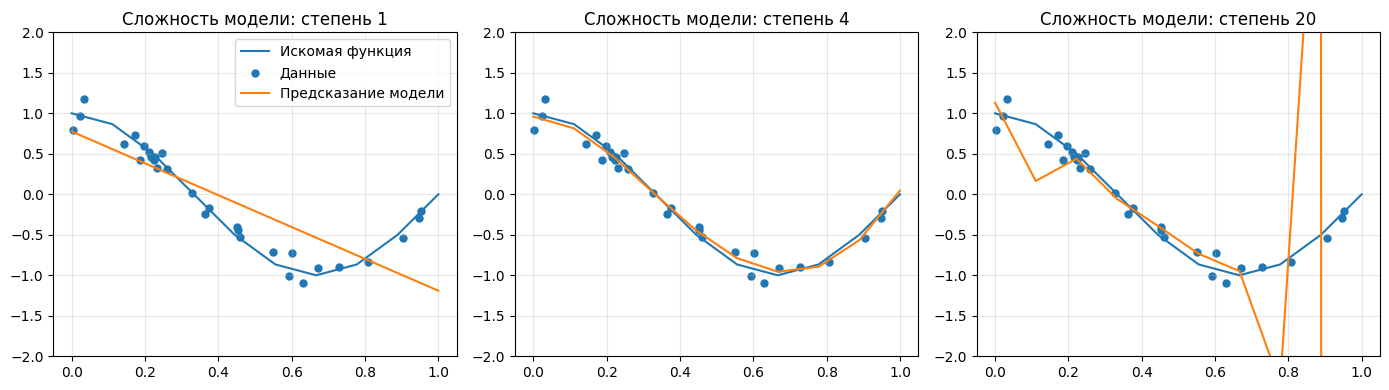

Слева: слишком простая (недообучение).
В центре: обычно разумный компромисс.
Справа: слишком гибкая — ловит шум (переобучение).


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
# Импортируем класс, который создаёт новые признаки из одного x: 1, x, x^2, x^3, ...

np.random.seed(36)
# Фиксируем генератор случайных чисел, чтобы результат был повторяемым.

# Плавная «настоящая» кривая (нам её знать не обязательно — это просто «истина» для картинки)
x_line = np.linspace(0, 1, 100)
# Создаём 100 равномерно распределённых точек от 0 до 1 для гладкой линии.

y_true_curve = np.cos(1.5 * np.pi * x_line)
# Считаем «истинную» функцию на этих точках, чтобы потом сравнить с моделью.

# 30 точек-наблюдений с шумом — «то, что видит модель»
x_points = np.random.uniform(0, 1, size=30) 
# Рандомные исходные значения
# Генерируем 30 случайных значений x в том же диапазоне, это наши обучающие точки.

y_points = np.cos(1.5 * np.pi * x_points) + np.random.normal(scale=0.1, size=30)
# Исходные значения с шумом. Из-за неё синие точки разбросаны.
# Берём значения истинной функции и добавляем шум, чтобы модель видела неидеальные данные.

fig, axs = plt.subplots(figsize=(14, 4), ncols=3)
# Создаём одну фигуру с тремя колонками, чтобы рядом сравнить разные степени полинома.

for i, degree in enumerate([1, 4, 20]):
    # PolynomialFeatures делает из x новые признаки: x, x^2, x^3, ...
    # degree=1  → почти обычная прямая
    # degree=20 → очень «гибкая» кривая, легко переобучается
    poly = PolynomialFeatures(degree)
    # Настраиваем преобразователь для текущей степени полинома.

    X_train = poly.fit_transform(x_points.reshape(-1, 1))
    # Преобразуем обучающие x в матрицу признаков: [1, x, x^2, ..., x^degree].
    # Подготавляиваем данные для обучения.

    X_line = poly.transform(x_line.reshape(-1, 1))
    # Преобразуем плотную сетку x для построения предсказаний той же самой трансформацией.

    regr = LinearRegression().fit(X_train, y_points)
    # Обучаем линейную модель на полиномиальных признаках.

    y_hat = regr.predict(X_line)
    # Делаем предсказания модели на плотной сетке x.

    axs[i].plot(x_line, y_true_curve, label="Искомая функция")
    # Рисуем «истинную» кривую — с ней будем сравнивать модель.

    axs[i].scatter(x_points, y_points, s=25, label="Данные")
    # Рисуем шумные наблюдения, которые видела модель при обучении.

    axs[i].plot(x_line, y_hat, label="Предсказание модели")
    # Рисуем кривую, которую предсказывает модель.

    axs[i].set_title(f"Сложность модели: степень {degree}")
    # Помечаем, какая степень полинома используется в этом графике.

    axs[i].set_ylim(-2, 2)
    # Ограничиваем вертикальный диапазон, чтобы все три графика были сравнимы.

    axs[i].grid(True, alpha=0.3)
    # Включаем сетку для удобства чтения графиков.

    if i == 0:
        axs[i].legend(loc="best")
    # Показываем легенду только на первом графике, чтобы не дублировать её три раза.

plt.tight_layout()
# Убираем наложения между подграфиками и метками.

plt.show()
# Отображаем готовую фигуру.

print("Слева: слишком простая (недообучение).")
print("В центре: обычно разумный компромисс.")
print("Справа: слишком гибкая — ловит шум (переобучение).")
# Комментарий к результату: что показывает каждый из трёх графиков.


### Как с этим жить на практике (запомнить)

1. Не гонитесь за «нулевой ошибкой» на обучающих данных.
2. Проверяйте модель на **новых** примерах (отложенная выборка / test set).
3. Начинайте с **простых** моделей — часто их хватает.

Про разбиение train/test подробно будет в следующих занятиях.
Сейчас главное — интуиция: **хорошая модель обобщает, а не зубрится**.


## 9. Словарь «учебный ноутбук → человеческий язык»

| В учебном ноутбуке | Простыми словами |
|---|---|
| `X` | Таблица признаков (вход: что знаем) |
| `y` | Ответы (выход: что предсказываем) |
| Признак / feature | Один столбец: площадь, возраст, температура… |
| Объект / sample | Одна строка: одна квартира, один клиент… |
| `model.fit(X, y)` | «Посмотри на примеры и подбери параметры» |
| `model.predict(X_new)` | «Дай ответ для новых примеров» |
| `model.coef_` | Множители перед признаками (`a`) |
| `model.intercept_` | Свободный член (`b`) |
| Шум / ε | Случайные отклонения в данных |
| MSE | «Средняя боль» от ошибок (с квадратом) |
| Полином | Формула $a_0 + a_1 x + a_2 x^2 + \ldots$ |
| Степень полинома | Самая высокая сила $x$; грубо — гибкость кривой |
| `PolynomialFeatures` | Делает из $x$ столбцы $1, x, x^2, \ldots$ |
| Переобучение | Вызубрил шум, плохо на новом |
| Sklearn | Готовая библиотека моделей |

### Соответствие разделам основного ноутбука

| Основной ноутбук | Где это здесь |
|---|---|
| Что такое ML | §1 |
| Подходы, supervised / unsupervised | §2 |
| `numpy` + случайный `X` | §5 |
| Формула `y = 25t + 100s − 42z + 81 + ε` | §5 |
| `LinearRegression`, `fit`, `coef_`, `intercept_` | §4–5 |
| Длинный вывод MSE и производных | §6 (только идея, без вывода) |
| Что такое полиномы | §7 |
| Картинки полиномов 1 / 4 / 20 | §8 |


## 10. Мини-практика (попробуйте сами)

Ниже — шаблон. Меняйте числа и смотрите, что происходит.

**Идеи для экспериментов:**
1. Увеличьте шум (например, `noise_scale = 1_000_000`) — станет ли модель хуже?
2. Добавьте больше квартир (`n_flats = 50`) — станут ли `a` и `b` ближе к 100000 и 500000?
3. Предскажите цену для площади 100 м² (уже есть в коде).


In [18]:
np.random.seed(1)

# --- ваши настройки ---
n_flats = 12                 # сколько квартир в данных
noise_scale = 250_000        # сила шума
true_price_per_m2 = 100_000
true_base = 500_000
# ----------------------

area2 = np.linspace(30, 90, n_flats)
price2 = true_price_per_m2 * area2 + true_base + np.random.normal(0, noise_scale, n_flats)

m = LinearRegression()
m.fit(area2.reshape(-1, 1), price2)

print(f"Найдено a ≈ {m.coef_[0]:,.0f}  (ждали ~{true_price_per_m2:,})")
print(f"Найдено b ≈ {m.intercept_:,.0f}  (ждали ~{true_base:,})")
print(f"Цена за 100 м² по модели: {m.predict([[100]])[0]:,.0f}")

Найдено a ≈ 97,791  (ждали ~100,000)
Найдено b ≈ 599,865  (ждали ~500,000)
Цена за 100 м² по модели: 10,378,929


## 11. Что делать дальше

1. **Перечитайте** этот ноутбук, запуская каждую ячейку.
2. Откройте **оригинал** `Введение_в_машинное_обучение.ipynb` — теперь там должно быть понятнее.
3. В длинном математическом блоке про MSE не застревайте: идея важнее вывода формул.
4. Когда будет комфортно — изучите:
   - разбиение на train/test;
   - другие модели (дерево решений — очень наглядное);
   - работу с реальными таблицами (`pandas` + CSV).

### Главная мысль всего занятия

> Машинное обучение — это когда компьютер **подбирает правила по примерам**,
> а не получает готовые `if/else` от программиста.

Линейная регрессия — самый спокойный способ это увидеть:
**подобрать числа в простой формуле** `y ≈ a₁x₁ + a₂x₂ + … + b`.

Удачи!
